In [9]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pyvista as pv
from desmin_reconstruction.plotting import line_and_bandplot
from desmin_reconstruction.plotting.renderings import render_pointcloud
from desmin_reconstruction.preprocessing.bbox import BoundingSquare
from desmin_reconstruction.voronoi import random_uniform_like, VoronoiAnalysis
from tqdm import tqdm


plt.rc("font", size=12)
plt.rc("grid", linestyle="--", color="lightgray")
plt.rc("axes.spines", right=False, top=False)
pv.set_jupyter_backend("static")

COLOR_DICT = {"desmin": "#FF0000", "actinin": "#00FF00"}

In [56]:
df = pl.read_csv("../data/STORM/desmin_alphaactinin_600nm.csv")
df = df.with_columns(*[pl.col(i) / 1000 for i in ("x", "y", "z")])
df = df.with_columns(*[pl.col(i) - pl.col(i).min() for i in ("x", "y", "z")])
out = df.partition_by("probe")
out = [o.unique(("x","y","z")) for o in out]

In [57]:
out

[shape: (76_797, 32)
 ┌──────────┬───────┬────────┬───────┬───┬───────┬────────┬────────┬────────┐
 │ image-ID ┆ cycle ┆ z-step ┆ frame ┆ … ┆ valid ┆ driftx ┆ drifty ┆ driftz │
 │ ---      ┆ ---   ┆ ---    ┆ ---   ┆   ┆ ---   ┆ ---    ┆ ---    ┆ ---    │
 │ i64      ┆ i64   ┆ i64    ┆ i64   ┆   ┆ i64   ┆ i64    ┆ i64    ┆ i64    │
 ╞══════════╪═══════╪════════╪═══════╪═══╪═══════╪════════╪════════╪════════╡
 │ 7598     ┆ 3     ┆ 0      ┆ 1598  ┆ … ┆ 1     ┆ 21     ┆ 0      ┆ 0      │
 │ 7620     ┆ 3     ┆ 0      ┆ 1620  ┆ … ┆ 1     ┆ 21     ┆ 0      ┆ 0      │
 │ 1940     ┆ 0     ┆ 0      ┆ 1940  ┆ … ┆ 1     ┆ 5      ┆ 0      ┆ 0      │
 │ 764      ┆ 0     ┆ 0      ┆ 764   ┆ … ┆ 1     ┆ 2      ┆ 0      ┆ 0      │
 │ 2081     ┆ 1     ┆ 0      ┆ 81    ┆ … ┆ 1     ┆ 5      ┆ 0      ┆ 0      │
 │ …        ┆ …     ┆ …      ┆ …     ┆ … ┆ …     ┆ …      ┆ …      ┆ …      │
 │ 7941     ┆ 3     ┆ 0      ┆ 1941  ┆ … ┆ 1     ┆ 22     ┆ 0      ┆ 0      │
 │ 7941     ┆ 3     ┆ 0      ┆ 1941  ┆ … ┆ 

In [58]:
out_unique

[shape: (76_797, 32)
 ┌──────────┬───────┬────────┬───────┬───┬───────┬────────┬────────┬────────┐
 │ image-ID ┆ cycle ┆ z-step ┆ frame ┆ … ┆ valid ┆ driftx ┆ drifty ┆ driftz │
 │ ---      ┆ ---   ┆ ---    ┆ ---   ┆   ┆ ---   ┆ ---    ┆ ---    ┆ ---    │
 │ i64      ┆ i64   ┆ i64    ┆ i64   ┆   ┆ i64   ┆ i64    ┆ i64    ┆ i64    │
 ╞══════════╪═══════╪════════╪═══════╪═══╪═══════╪════════╪════════╪════════╡
 │ 31       ┆ 0     ┆ 0      ┆ 31    ┆ … ┆ 1     ┆ 0      ┆ 0      ┆ 0      │
 │ 248      ┆ 0     ┆ 0      ┆ 248   ┆ … ┆ 1     ┆ 0      ┆ 0      ┆ 0      │
 │ 2020     ┆ 1     ┆ 0      ┆ 20    ┆ … ┆ 1     ┆ 5      ┆ 0      ┆ 0      │
 │ 3451     ┆ 1     ┆ 0      ┆ 1451  ┆ … ┆ 1     ┆ 9      ┆ 0      ┆ 0      │
 │ 7963     ┆ 3     ┆ 0      ┆ 1963  ┆ … ┆ 1     ┆ 22     ┆ 0      ┆ 0      │
 │ …        ┆ …     ┆ …      ┆ …     ┆ … ┆ …     ┆ …      ┆ …      ┆ …      │
 │ 5137     ┆ 2     ┆ 0      ┆ 1137  ┆ … ┆ 1     ┆ 14     ┆ 0      ┆ 0      │
 │ 3505     ┆ 1     ┆ 0      ┆ 1505  ┆ … ┆ 

Text(0.5, 0.01, 'x (μm)')

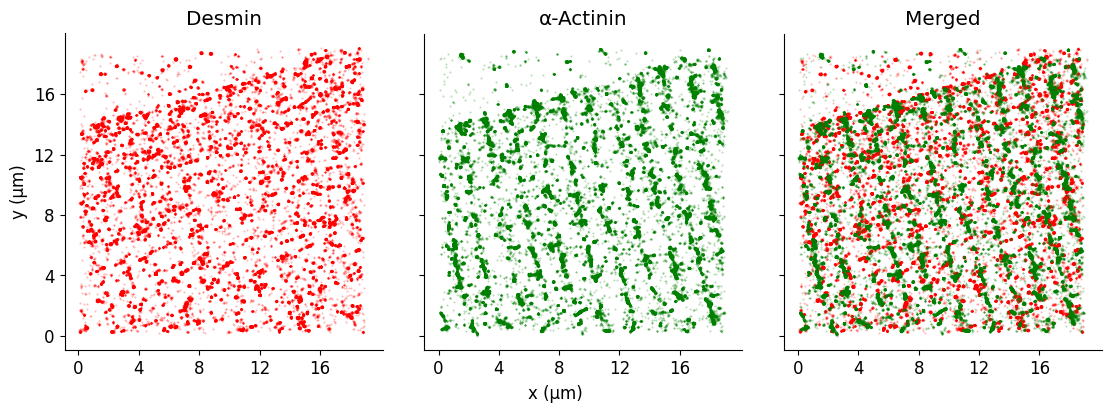

In [59]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(11, 4),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.1},
)
for i in (0, 2):
    axes[i].scatter(
        out[0]["x"],
        out[0]["y"],
        s=0.2,
        c="red",
        # c=np.log10(out[0]["amp"]),
        # cmap=cc.cm.kr_r,
        alpha=0.3,
    )
for i in (1, 2):
    axes[i].scatter(
        out[1]["x"],
        out[1]["y"],
        s=0.2,
        c="green",
        # c=np.log10(out[1]["amp"]),
        # cmap=cc.cm.kg_r,
        alpha=0.3,
    )

for ax, title in zip(axes, ("Desmin", "α-Actinin", "Merged")):
    ax.set_aspect("equal", "box")
    # ax.set_xlim((-0.2, 19.3))
    # ax.set_ylim((-0.2, 19.3))
    ax.set_xticks(np.arange(0, 20, 4))
    ax.set_yticks(np.arange(0, 20, 4))
    ax.set_title(title)
axes[0].set_ylabel("y (μm)")
fig.supxlabel("x (μm)", fontsize="medium")

In [60]:
voros = [VoronoiAnalysis(o.select(["x", "y"]).to_numpy()) for o in out]
voro_vols = [v.region_volumes for v in voros]

100%|██████████| 154160/154160 [00:14<00:00, 10846.33it/s]


In [61]:
voro_vols

[array([1.41988830e-05, 3.83221437e-05, 2.58372218e-02, ...,
        5.09032107e-05, 4.70630476e-05, 4.49735563e-05], shape=(76797,)),
 array([1.36119934e-03, 5.75381211e-05, 9.30224103e-05, ...,
        5.90881624e-05, 1.53661038e-05, 2.01772288e-06], shape=(154160,))]

Text(0.5, 0.01, 'x (μm)')

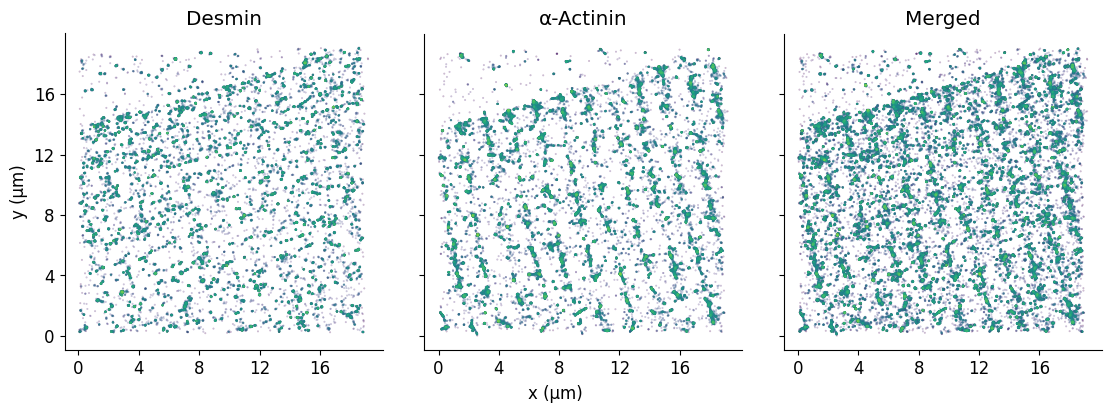

In [62]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(11, 4),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.1},
)
for i in (0, 2):
    axes[i].scatter(
        out[0]["x"],
        out[0]["y"],
        s=0.2,
        c=np.log10(1/voro_vols[0]+1e-6),
        # c=np.log10(out[0]["amp"]),
        # cmap=cc.cm.kr_r,
        vmin=0,
        alpha=0.3,
    )
for i in (1, 2):
    axes[i].scatter(
        out[1]["x"],
        out[1]["y"],
        s=0.2,
        c=np.log10(1/voro_vols[1]+1e-6),
        # c=np.log10(out[1]["amp"]),
        # cmap=cc.cm.kg_r,
        vmin=0,
        alpha=0.3,
    )

for ax, title in zip(axes, ("Desmin", "α-Actinin", "Merged")):
    ax.set_aspect("equal", "box")
    # ax.set_xlim((-0.2, 19.3))
    # ax.set_ylim((-0.2, 19.3))
    ax.set_xticks(np.arange(0, 20, 4))
    ax.set_yticks(np.arange(0, 20, 4))
    ax.set_title(title)
axes[0].set_ylabel("y (μm)")
fig.supxlabel("x (μm)", fontsize="medium")

(array([2.1000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 3.0000e+00,
        4.0000e+00, 2.0000e+00, 1.0000e+00, 3.0000e+00, 4.0000e+00,
        3.0000e+00, 4.0000e+00, 9.0000e+00, 4.0000e+00, 6.0000e+00,
        1.1000e+01, 1.1000e+01, 1.9000e+01, 1.0000e+01, 3.3000e+01,
        4.7000e+01, 9.7000e+01, 1.5800e+02, 2.6100e+02, 3.9000e+02,
        5.6100e+02, 6.3800e+02, 7.5700e+02, 8.8100e+02, 9.2600e+02,
        9.9600e+02, 1.0240e+03, 1.0740e+03, 1.1980e+03, 1.2300e+03,
        1.2560e+03, 1.3890e+03, 1.5350e+03, 1.7180e+03, 2.0920e+03,
        2.2250e+03, 2.7870e+03, 3.3720e+03, 3.89

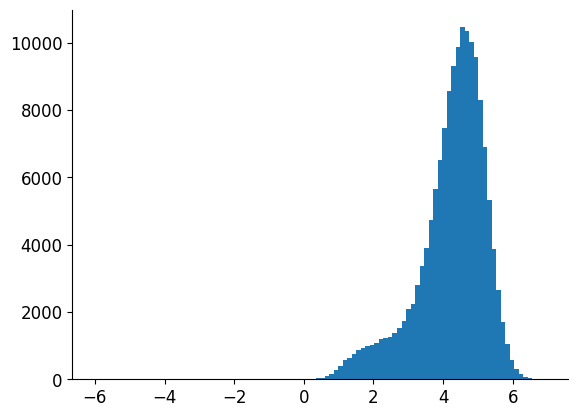

In [63]:
plt.hist(np.log10(1/voro_vols[1]+1e-6), bins=100)

In [65]:
out_concat=[pl.concat((o, pl.DataFrame({"voronoi_volume": voro_vols[i]})), how="horizontal") for i, o in enumerate(out)]
out_concat[0].head()

image-ID,cycle,z-step,frame,accum,probe,photon-count,photon-count11,photon-count12,photon-count21,photon-count22,psfx,psfy,psfz,psf-photon-count,x,y,z,stdev,amp,background11,background12,background21,background22,chisq,log-likelihood,accuracy,fiducial,valid,driftx,drifty,driftz,voronoi_volume
i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,f64
7598,3,0,1598,1,0,2563.5,1302.74,1260.76,0.0,0.0,63.0552,72.6321,55.341,3073.24,14.969847,18.110549,0.718471,0,102.759,31.1168,36.1774,0.0,0.0,150.034,-881.537,7.94813,0,1,21,0,0,0.000014
7620,3,0,1620,1,0,1477.73,728.598,749.13,0.0,0.0,27.6567,9.65553,4.97489,1118.06,2.846687,14.486049,0.768837,0,37.3233,31.8095,37.6038,0.0,0.0,57.3271,-818.254,17.0105,0,1,21,0,0,0.000038
1940,0,0,1940,1,0,2342.2,1128.06,1214.14,0.0,0.0,18.6502,-14.4599,30.9598,1788.85,1.161477,11.819349,0.742852,0,60.4741,41.0294,49.5812,0.0,0.0,146.322,-904.477,9.91474,0,1,5,0,0,0.025837
764,0,0,764,1,0,1085.63,603.658,481.967,0.0,0.0,33.9727,94.5361,98.3404,727.043,3.239017,14.700149,0.675472,0,24.5337,34.1076,40.0364,0.0,0.0,57.2107,-822.196,27.6758,0,1,2,0,0,0.000035
2081,1,0,81,1,0,2621.92,1246.11,1375.81,0.0,0.0,18.7312,44.8386,-124.622,3121.75,10.330147,14.550549,0.898434,0,100.447,39.6905,46.4663,0.0,0.0,67.5195,-869.921,8.3504,0,1,5,0,0,0.000017


In [66]:
from desmin_reconstruction.preprocessing.bbox import BoundingSquare, filter_bounded

bbox = BoundingSquare(8, 0, side=8)
points_filtered = [filter_bounded(o.select(["x", "y"]).to_numpy(),bbox) for o in out]

In [67]:
out_filtered = [o.filter(pl.col("x")>=bbox.x0, pl.col("x")<bbox.x1, pl.col("y")>=bbox.y0, pl.col("y")<bbox.y1) for o in out_concat]
out_filtered[0].head()

image-ID,cycle,z-step,frame,accum,probe,photon-count,photon-count11,photon-count12,photon-count21,photon-count22,psfx,psfy,psfz,psf-photon-count,x,y,z,stdev,amp,background11,background12,background21,background22,chisq,log-likelihood,accuracy,fiducial,valid,driftx,drifty,driftz,voronoi_volume
i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,f64
7361,3,0,1361,1,0,1484.44,655.192,829.246,0.0,0.0,14.413,-43.0628,-144.221,1626.7,10.035447,6.067709,0.918033,0,53.3004,32.846,42.4185,0.0,0.0,84.4592,-846.334,17.4749,0,1,20,0,0,0.000028
2738,1,0,738,1,0,1662.3,799.222,863.075,0.0,0.0,-30.365,26.7202,-93.2376,1622.04,11.475447,0.616289,0.86705,0,52.86,35.1448,42.9621,0.0,0.0,61.6224,-840.575,15.1138,0,1,7,0,0,0.000011
6956,3,0,956,1,0,2784.95,1229.4,1555.55,0.0,0.0,27.2375,53.2005,-179.662,3144.11,9.823347,4.675869,0.953474,0,100.455,34.7523,43.25,0.0,0.0,97.3784,-872.332,7.45414,0,1,19,0,0,7.4863e-7
2360,1,0,360,1,0,1751.86,799.629,952.231,0.0,0.0,-12.4281,55.3467,-102.799,1491.34,8.467737,3.278479,0.876611,0,48.1731,39.1084,48.2767,0.0,0.0,91.7342,-870.659,14.7172,0,1,6,0,0,0.003343
7216,3,0,1216,1,0,6380.65,2958.16,3422.49,0.0,0.0,46.4442,46.415,-135.603,7861.03,9.804147,4.682659,0.909415,0,252.212,35.4801,40.7966,0.0,0.0,176.786,-942.763,2.67778,0,1,20,0,0,0.00001


Text(0.5, 0.01, 'x (μm)')

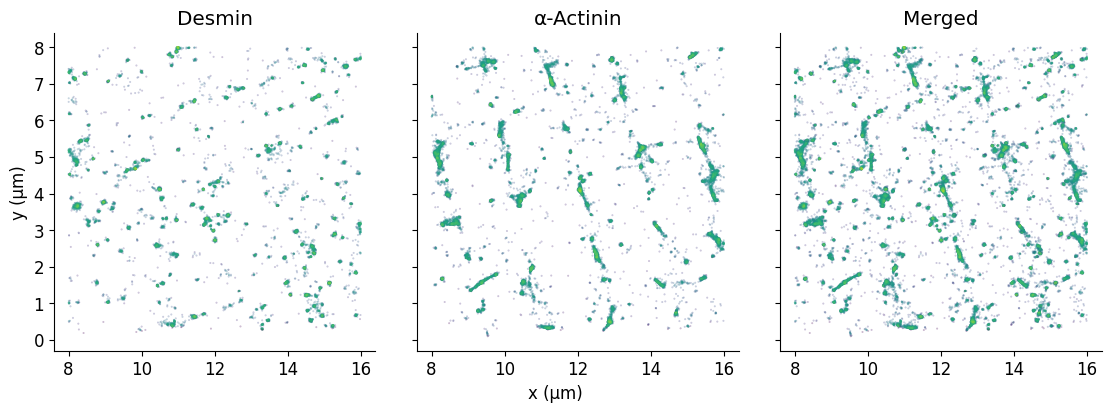

In [68]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(11, 4),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={"wspace": 0.1},
)
for i in (0, 2):
    axes[i].scatter(
        out_filtered[0]["x"], out_filtered[0]["y"],
        s=0.2,
        c=np.log10(1/out_filtered[0]["voronoi_volume"]+1e-6),
        # cmap=cc.cm.kr_r,
        vmin=0,
        alpha=0.3,
    )
for i in (1, 2):
    axes[i].scatter(
        out_filtered[1]["x"], out_filtered[1]["y"],
        s=0.2,
        c=np.log10(1/out_filtered[1]["voronoi_volume"]+1e-6),
        # cmap=cc.cm.kg_r,
        vmin=0,
        alpha=0.3,
    )

for ax, title in zip(axes, ("Desmin", "α-Actinin", "Merged")):
    ax.set_aspect("equal", "box")
    # ax.set_xlim((-0.2, 19.3))
    # ax.set_ylim((-0.2, 19.3))
    ax.set_title(title)
axes[0].set_ylabel("y (μm)")
fig.supxlabel("x (μm)", fontsize="medium")

In [69]:
out_filtered[0].select("voronoi_volume").to_numpy().shape

(13136, 1)

In [70]:
np.unique(out_filtered[0].select("voronoi_volume").to_numpy(),axis=0).shape

(13136, 1)

In [238]:
import scipy.interpolate as scinterp

#rbf =scinterp.RBFInterpolator(out_filtered[0].select(["x", "y"]).to_numpy(), np.log10(1/out_filtered[0].select("voronoi_volume").to_numpy()+1e-3), kernel="gaussian",epsilon=0.1)
rbf =scinterp.CloughTocher2DInterpolator(out_filtered[0].select(["x", "y"]).to_numpy(), np.log10(1/out_filtered[0].select("voronoi_volume").to_numpy()+1e-3))

In [239]:
from einops import rearrange
grid = np.asarray(np.meshgrid(np.arange(bbox.x0, bbox.x1+0.02, 0.02),np.arange(bbox.y0, bbox.y1+0.02, 0.02), indexing='ij'))
print(grid.shape)
grid_flat = rearrange(grid, "d x y -> (x y) d")
print(grid_flat.shape)

(2, 401, 401)
(160801, 2)


In [240]:
res_flat = rbf(grid_flat)

In [241]:
res = rearrange(res_flat, "(x y) 1 -> x y", x=grid.shape[1])
res.shape

(401, 401)

In [242]:
res

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(401, 401))

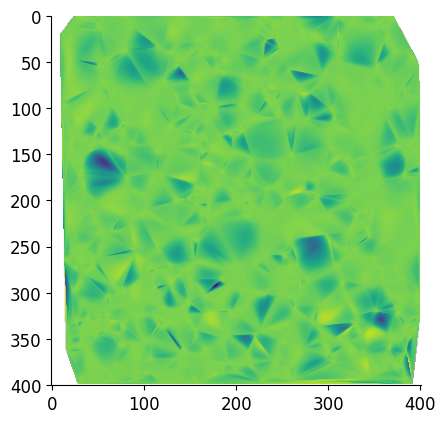

In [243]:
plt.imshow(res)

In [236]:
import skimage
bin=res>skimage.filters.threshold_multiotsu(res,classes=4)[2]


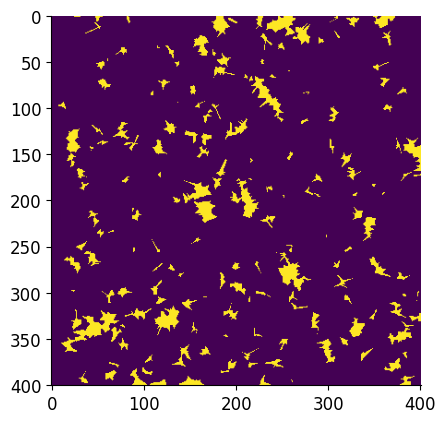

In [237]:
plt.imshow(bin)

In [216]:
np.log10(1/out_filtered[0].select("voronoi_volume").to_numpy()+1e-3)

array([[4.55308852],
       [4.958827  ],
       [6.12573528],
       ...,
       [4.6225396 ],
       [2.88564589],
       [4.32731997]], shape=(13136, 1))

In [312]:
import polars as pl
df = pl.read_csv("../data/results/desmin_alphaactinin_600nm_filtered.csv")
points = {
    name: df_.select(["x", "y","z"]).to_numpy()
    for name, df_ in zip(("desmin", "actinin"), df.partition_by("probe"))
}

In [313]:
bbox = BoundingSquare(6, 0, side=10)

In [ ]:
bbox = BoundingSquare(6, 0, side=10)
points_roi = {k:filter_bounded(v, bbox) for k, v in points.items()}

In [315]:
import alphashape

shape = alphashape.alphashape(points_roi["actinin"], alpha=.0)

In [354]:
mesh_actinin=pv.wrap(alphashape.alphashape(points_roi["actinin"], alpha=15.0))
mesh_desmin=pv.wrap(alphashape.alphashape(points_roi["desmin"], alpha=15.0))

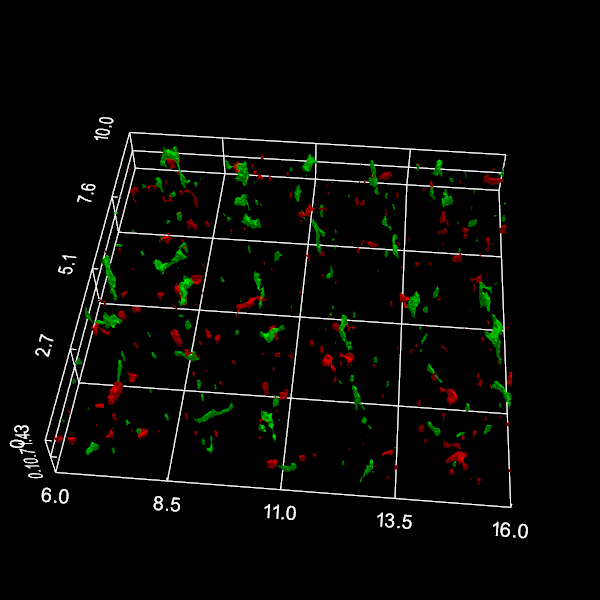

In [356]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    mesh_desmin,
    color="#FF0000",
    show_scalar_bar=False,
)

p.add_mesh(
    mesh_actinin,
    color="#00FF00",
    show_scalar_bar=False,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

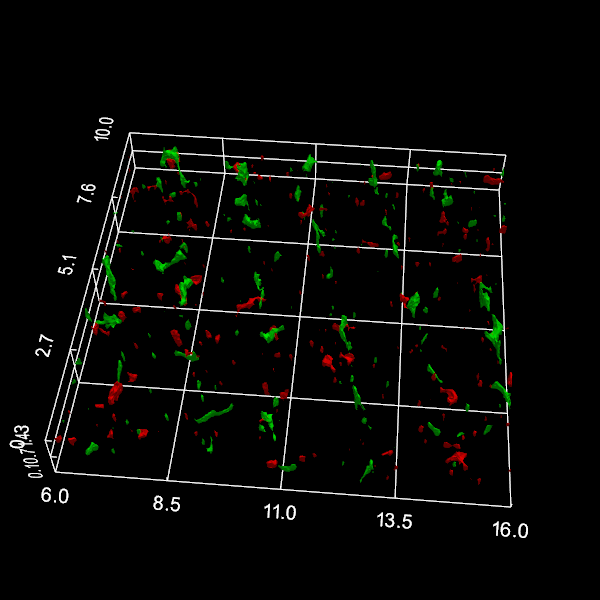

In [357]:
pl = pv.Plotter(notebook=True, window_size=(600, 600))
pl.add_mesh(
    mesh_desmin.smooth_taubin(n_iter=10),
    color="#FF0000",
    show_scalar_bar=False,
)

pl.add_mesh(
    mesh_actinin.smooth_taubin(n_iter=10),
    color="#00FF00",
    show_scalar_bar=False,
)
pl.set_background("black")
# pl.view_xy()
axis = pl.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
pl.camera.azimuth = 230
pl.camera.elevation = 15
# pl.camera.zoom(0.8)
pl.show()

In [327]:
bbox = BoundingSquare(6, 0, side=5)
points_test = {k:filter_bounded(v, bbox) for k, v in points.items()}

In [347]:
shape=alphashape.alphashape(points_test["actinin"], alpha=15.0)

In [348]:
alpha = alphashape.optimizealpha(points_test["actinin"],upper=10, max_iterations=3)

KeyboardInterrupt: 

In [ ]:
alpha

0.0

In [349]:
shape

<trimesh.Trimesh(vertices.shape=(3036, 3), faces.shape=(5954, 3))>

In [350]:
type(shape)

trimesh.base.Trimesh

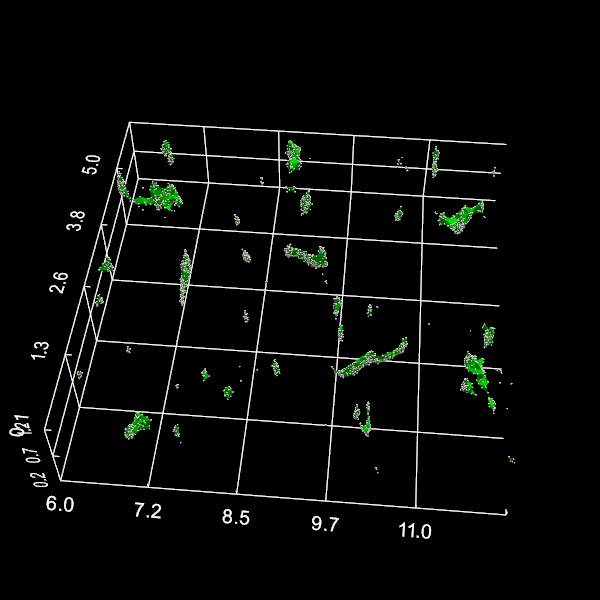

In [353]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
# p.add_mesh(
#     mesh_desmin,
#     color="#FF0000",
#     show_scalar_bar=False,
# )
p.add_mesh(
    pv.wrap(points_test["actinin"]),
    color="white",
    render_points_as_spheres=True,
    point_size=2,
    show_scalar_bar=False,
)
p.add_mesh(
    pv.wrap(shape),
    color="#00FF00",
    show_scalar_bar=False,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()